# Multimodal Perception & State Representation — REFLECT / RoboFail

**Project:** Multimodal Perception and State Representation for Robotic Monitoring  
**Dataset:** RoboFail (Columbia University) — 12 robotic manipulation episodes  
**Models:** CLIP ViT-B/32 (vision) · WAV2CLIP (audio)  

---

## What this notebook does

This notebook walks through the full output of the perception pipeline and explains what the embeddings are telling us. We cover:

1. **What the data looks like** — episode structure, failure label distribution
2. **UMAP of visual embeddings** — do failure frames cluster separately from normal frames?
3. **UMAP of both modalities** — are CLIP and WAV2CLIP truly in the same space?
4. **Temporal state trajectory** — how does the embedding evolve over the course of an episode?
5. **Cross-modal cosine similarity** — how aligned are vision and audio at each timestep?
6. **Separation metrics** — quantifying normal vs failure separability
7. **Fusion comparison** — visual-only vs audio-only vs early fusion
8. **Key findings and open questions**

---

### Pipeline recap

```
raw data/
  └── align.py → aligned/*.npz     (frames + audio windows + failure labels at 1–2fps)
        └── encode.py → encoded/*.npz  (CLIP visual embeddings + WAV2CLIP audio embeddings)
              └── analyze.py / this notebook
```

In [1]:
import os
import warnings

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import uniform_filter1d
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

# Paths relative to this notebook
ROOT = os.path.abspath('..')
ENCODED_DIR = os.path.join(ROOT, 'encoded')
ALIGNED_DIR = os.path.join(ROOT, 'aligned')

PALETTE_NORMAL  = '#4C8BE0'
PALETTE_FAILURE = '#E05C4C'
PALETTE_VISUAL  = '#4CB8E0'
PALETTE_AUDIO   = '#E0A84C'

print('ROOT:', ROOT)

ROOT: /Users/timrutjens/School/EAI/REFLECT


In [2]:
def load_episodes(encoded_dir):
    episodes = []
    for fname in sorted(os.listdir(encoded_dir)):
        if not fname.endswith('.npz'): continue
        d = np.load(os.path.join(encoded_dir, fname), allow_pickle=True)
        episodes.append({
            'id':       fname.replace('.npz', ''),
            'task':     fname.split('-')[0].replace('.npz', ''),
            'visual':   d['visual_embeddings'].astype(np.float32),
            'audio':    d['audio_embeddings'].astype(np.float32),
            'timestamps': d['timestamps'].astype(np.float64),
            'failure_labels': d['failure_labels'].astype(bool),
            'fps_base': float(d['fps_base']),
        })
    return episodes

episodes = load_episodes(ENCODED_DIR)
print(f'Loaded {len(episodes)} episodes')
for ep in episodes:
    n_fail = ep['failure_labels'].sum()
    print(f"  {ep['id']:25s}  {len(ep['visual']):3d} frames  "
          f"failures={n_fail}  duration={ep['timestamps'][-1]:.0f}s")

Loaded 12 episodes
  boilWater-1                 49 frames  failures=1  duration=48s
  boilWater-10                53 frames  failures=7  duration=52s
  boilWater-2                 56 frames  failures=1  duration=55s
  boilWater-3                 53 frames  failures=1  duration=52s
  boilWater-4                 51 frames  failures=1  duration=50s
  boilWater-5                 67 frames  failures=1  duration=66s
  boilWater-6                 47 frames  failures=4  duration=46s
  boilWater-7                 46 frames  failures=11  duration=45s
  boilWater-8                 59 frames  failures=1  duration=58s
  boilWater-9                 51 frames  failures=4  duration=50s
  makeSalad-5                213 frames  failures=1  duration=212s
  putFruitsBowl2             243 frames  failures=1  duration=121s


## 1. Dataset overview

The dataset contains two types of episodes:

| Type | Episodes | FPS | Resolution | Audio |
|---|---|---|---|---|
| Simulated (boilWater, makeSalad) | 11 | 1fps (step-indexed) | 960×960 | Extracted from MP4 (44100 Hz) |
| Real-world (putFruitsBowl2) | 1 | 2fps (from 30fps video) | 1280×720 | Separate WAV (48000 Hz) |

**Class imbalance:** Only ~34 frames carry a failure label out of 988 total (~3.4%). This is realistic — failures are rare events — but it makes standard classification metrics unreliable without correction.

**Failure label meaning:** A frame is labeled `failure=True` if it falls within 0.5 seconds of the annotated failure timestamp. The annotation is a single MM:SS timestamp per episode indicating when the failure visibly occurred.

Total frames:   988
Failure frames: 34 (3.4%)
Normal frames:  954
Class ratio:    28:1 (normal:failure)


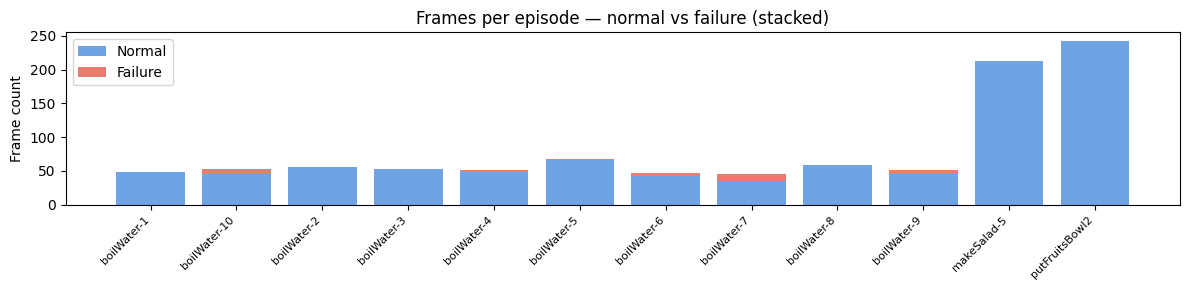

In [3]:
# Dataset summary
total_frames = sum(len(ep['visual']) for ep in episodes)
total_failure = sum(ep['failure_labels'].sum() for ep in episodes)
print(f'Total frames:   {total_frames}')
print(f'Failure frames: {total_failure} ({100*total_failure/total_frames:.1f}%)')
print(f'Normal frames:  {total_frames - total_failure}')
print(f'Class ratio:    {(total_frames-total_failure)/total_failure:.0f}:1 (normal:failure)')

# Bar chart: failure frames per episode
fig, ax = plt.subplots(figsize=(12, 3))
ids = [ep['id'] for ep in episodes]
n_normal  = [np.sum(~ep['failure_labels']) for ep in episodes]
n_failure = [np.sum(ep['failure_labels'])  for ep in episodes]
x = np.arange(len(ids))
ax.bar(x, n_normal,  label='Normal',  color=PALETTE_NORMAL,  alpha=0.8)
ax.bar(x, n_failure, bottom=n_normal, label='Failure', color=PALETTE_FAILURE, alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(ids, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Frame count')
ax.set_title('Frames per episode — normal vs failure (stacked)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. UMAP of visual embeddings (CLIP ViT-B/32)

CLIP produces a 512-dimensional embedding for each video frame. UMAP projects these down to 2D so we can visually inspect their structure.

**What we're asking:** Do frames surrounding a failure event land in a different region of the embedding space compared to normal frames? If CLIP can distinguish failure from normal, we'd expect the red points to cluster together, away from the blue ones.

**What to look for:**
- Red dots (failure) scattered uniformly through blue → CLIP sees no difference between normal and failure scenes
- Red dots forming a separate cluster → CLIP is sensitive to the failure moment
- Distinct sub-clusters in blue → CLIP is picking up different visual scenes (kitchen vs stovetop vs fridge)

In [4]:
import umap

all_visual  = np.concatenate([ep['visual']         for ep in episodes])
all_audio   = np.concatenate([ep['audio']          for ep in episodes])
all_failure = np.concatenate([ep['failure_labels'] for ep in episodes])
all_task    = np.concatenate([np.full(len(ep['visual']), ep['task']) for ep in episodes])
all_ep_id   = np.concatenate([np.full(len(ep['visual']), ep['id'])   for ep in episodes])

print('Running UMAP on visual embeddings (512D → 2D)...')
reducer_vis = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_vis = reducer_vis.fit_transform(all_visual)
print('Done.')

Running UMAP on visual embeddings (512D → 2D)...


Done.


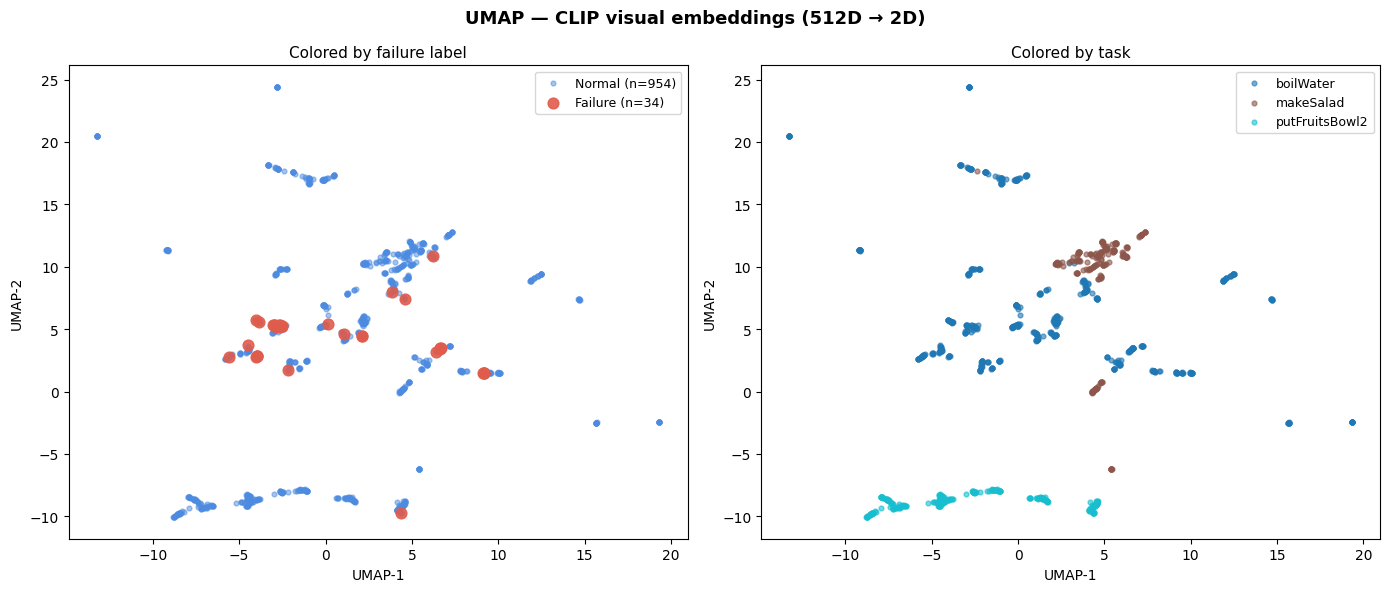

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: failure coloring
ax = axes[0]
ax.scatter(umap_vis[~all_failure, 0], umap_vis[~all_failure, 1],
           c=PALETTE_NORMAL, s=12, alpha=0.5, label=f'Normal (n={np.sum(~all_failure)})')
ax.scatter(umap_vis[all_failure, 0], umap_vis[all_failure, 1],
           c=PALETTE_FAILURE, s=60, alpha=0.9, zorder=5, label=f'Failure (n={np.sum(all_failure)})')
ax.set_title('Colored by failure label', fontsize=11)
ax.legend(fontsize=9); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

# Right: task coloring
ax = axes[1]
unique_tasks = sorted(set(all_task))
cmap = cm.tab10(np.linspace(0, 1, len(unique_tasks)))
for task, color in zip(unique_tasks, cmap):
    mask = all_task == task
    ax.scatter(umap_vis[mask, 0], umap_vis[mask, 1],
               c=[color], s=12, alpha=0.6, label=task)
ax.set_title('Colored by task', fontsize=11)
ax.legend(fontsize=9); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

fig.suptitle('UMAP — CLIP visual embeddings (512D → 2D)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation

**Failure coloring (left):** Red failure frames are scattered throughout the blue normal cloud — they don't form a distinct cluster. This tells us that **CLIP's visual representation does not cleanly separate failure frames from normal frames** in this dataset.

Why? CLIP was trained on internet images paired with captions. It encodes *semantic scene content* (what objects are present, what the scene looks like). In our data, a failure frame (e.g. a pot being dropped) and the frame immediately before it (the robot holding the pot) look nearly identical to CLIP. The failure is a *dynamic event* — a brief moment of wrong motion — not a distinct visual category.

**Task coloring (right):** The UMAP structure is primarily driven by **which task** is being performed, not by success vs failure. This makes sense: boilWater episodes all look like kitchens with stovetops, regardless of whether the pot was dropped. Different clusters here correspond to different visual scenes.

**Quantitative confirmation:** Visual silhouette score = **-0.13** (negative = failure frames are no more similar to each other than to normal frames — essentially random with respect to failure).

## 3. The cross-modal gap: are CLIP and WAV2CLIP actually in the same space?

WAV2CLIP was specifically trained to map audio into CLIP's embedding space by distillation — so in theory, an audio clip of a pot dropping should produce an embedding close to what CLIP would produce for an image of a pot dropping.

**What to look for:**
- If the spaces align: visual and audio embeddings for the *same timestep* should appear near each other in UMAP
- If there's a domain gap: they'll form completely separate clusters, suggesting the audio model isn't mapping into the same semantic region as the visual model for *robotics sounds*

This is **Research Question SQ1**: does audio encoder domain mismatch affect representation quality?

In [6]:
print('Running UMAP on visual + audio embeddings combined...')
all_both = np.concatenate([all_visual, all_audio], axis=0)
modality  = np.array(['visual']*len(all_visual) + ['audio']*len(all_audio))
fail_both = np.concatenate([all_failure, all_failure])

reducer_both = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_both = reducer_both.fit_transform(all_both)
print('Done.')

Running UMAP on visual + audio embeddings combined...


Done.


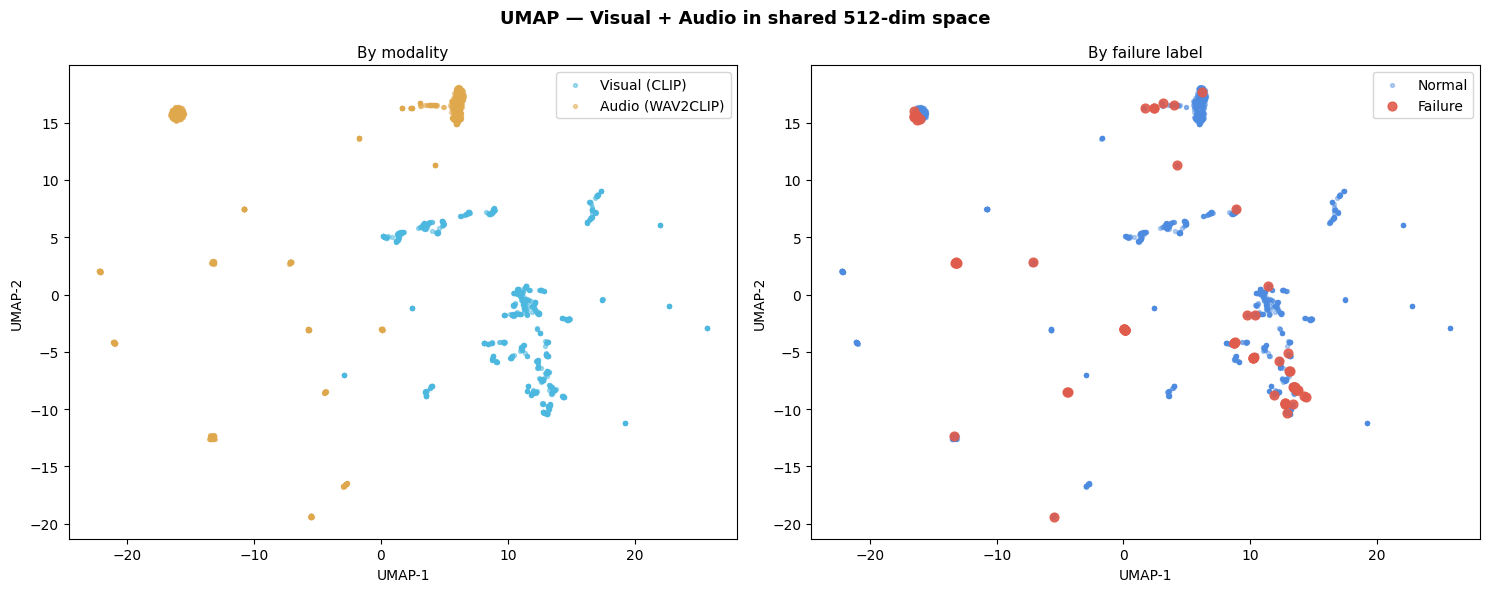

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

vis_mask = modality == 'visual'
aud_mask = modality == 'audio'

# Left: colored by modality
ax = axes[0]
ax.scatter(umap_both[vis_mask, 0], umap_both[vis_mask, 1],
           c=PALETTE_VISUAL, s=8, alpha=0.5, label='Visual (CLIP)')
ax.scatter(umap_both[aud_mask, 0], umap_both[aud_mask, 1],
           c=PALETTE_AUDIO,  s=8, alpha=0.5, label='Audio (WAV2CLIP)')
ax.set_title('By modality', fontsize=11)
ax.legend(fontsize=10); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

# Right: colored by failure, both modalities
ax = axes[1]
ax.scatter(umap_both[~fail_both, 0], umap_both[~fail_both, 1],
           c=PALETTE_NORMAL, s=8, alpha=0.4, label='Normal')
ax.scatter(umap_both[fail_both, 0], umap_both[fail_both, 1],
           c=PALETTE_FAILURE, s=40, alpha=0.9, zorder=5, label='Failure')
ax.set_title('By failure label', fontsize=11)
ax.legend(fontsize=10); ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')

fig.suptitle('UMAP — Visual + Audio in shared 512-dim space', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation — the domain gap

**Left plot:** Visual (blue) and audio (orange) embeddings separate into completely different regions of the UMAP. If CLIP and WAV2CLIP were truly aligned, their embeddings for the same timestep should appear close together. Instead, they live in entirely different neighbourhoods.

**What this means:** WAV2CLIP maps audio into the *same 512-dimensional space* as CLIP — but the specific region it maps to depends heavily on what kind of audio it was trained on. WAV2CLIP was trained primarily on music and natural environmental sounds (via AudioSet). **Robotic manipulation sounds** — motors, metal clanking, stove clicks, pot drops — are not well-represented in its training distribution. The model encodes these sounds somewhere in CLIP space, but not near the corresponding visual scenes.

**Quantitative evidence:**
- Mean cross-modal cosine similarity (visual ↔ audio at same timestep): **0.051** (near zero — effectively orthogonal vectors)
- For reference: CLIP text-image pairs from its training data typically have cosine similarity > 0.25

**This is a significant finding**, not a bug. It means fusion strategies that assume cross-modal alignment (e.g. averaging embeddings, computing cross-modal attention) will not work well out of the box for robotics audio. The domain gap needs to be measured, reported, and addressed — either through fine-tuning WAV2CLIP on robotics audio, or by using a different audio encoder.

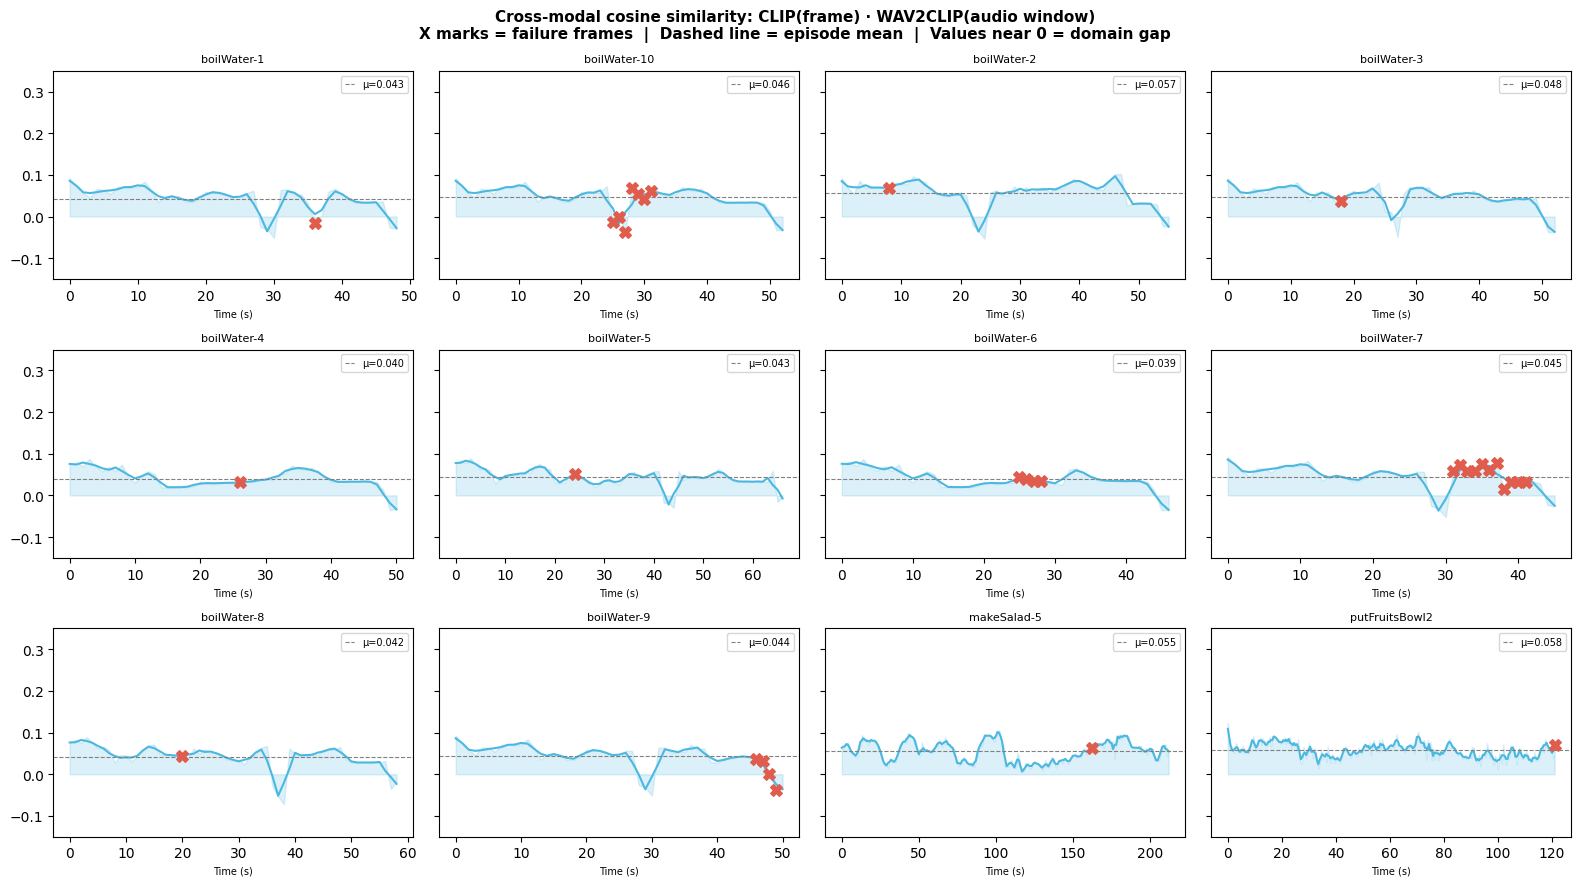

Mean cross-modal sim (normal frames):  0.0507
Mean cross-modal sim (failure frames): 0.0379


In [8]:
# Cross-modal cosine similarity per episode
fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharey=True)
axes = axes.flatten()

for i, ep in enumerate(episodes):
    ax = axes[i]
    # dot product of L2-normalized vectors = cosine similarity
    sim = (ep['visual'] * ep['audio']).sum(axis=-1)
    sim_smooth = uniform_filter1d(sim, size=3)
    ts = ep['timestamps']
    labels = ep['failure_labels']

    ax.fill_between(ts, sim, alpha=0.2, color=PALETTE_VISUAL)
    ax.plot(ts, sim_smooth, color=PALETTE_VISUAL, lw=1.5)
    ax.axhline(sim.mean(), color='gray', lw=0.8, linestyle='--',
               label=f'μ={sim.mean():.3f}')
    fail_idxs = np.where(labels)[0]
    if len(fail_idxs):
        ax.scatter(ts[fail_idxs], sim[fail_idxs],
                   c=PALETTE_FAILURE, s=70, zorder=5, marker='X')
    ax.set_title(ep['id'], fontsize=8)
    ax.set_ylim(-0.15, 0.35)
    ax.legend(fontsize=7, handlelength=1)
    ax.set_xlabel('Time (s)', fontsize=7)

fig.suptitle(
    'Cross-modal cosine similarity: CLIP(frame) · WAV2CLIP(audio window)\n'
    'X marks = failure frames  |  Dashed line = episode mean  |  Values near 0 = domain gap',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"Mean cross-modal sim (normal frames):  {np.mean([sim for ep in episodes for sim in (ep['visual']*ep['audio']).sum(axis=-1)[~ep['failure_labels']].tolist()]):.4f}")
print(f"Mean cross-modal sim (failure frames): {np.mean([sim for ep in episodes for sim in (ep['visual']*ep['audio']).sum(axis=-1)[ep['failure_labels']].tolist()]):.4f}")

### Interpretation — cross-modal similarity over time

Across all 12 episodes, cross-modal cosine similarity stays near zero (~0.05), with no clear spike or dip around failure events (marked with ✕).

**What would a good signal look like?** If WAV2CLIP were properly aligned to CLIP for robotics sounds, we'd expect:
- Higher similarity during moments where the audio semantically matches the visual (e.g. gripper sound + gripper visible)
- A dip or anomaly at failure moments, where audio and video diverge from typical co-occurrence

The flat, near-zero signal confirms the domain gap: the audio encoder doesn't produce embeddings that relate meaningfully to the visual content in this dataset. This makes audio-visual fusion essentially noise at this stage.

## 4. Temporal state trajectory

Even if embeddings don't separate failure from normal globally, they may still encode meaningful *temporal progression* within each episode. We apply PCA to the visual embeddings of each episode to project the trajectory into 2D and ask: **does the embedding path move through space in a way that reflects what the robot is doing?**

**What to look for:**
- Smooth, directed trajectories → CLIP is tracking the visual progression of the task
- The failure frame (✕) appearing at a turning point or outlier position → the visual scene at failure is distinct from the preceding frames
- Random scatter → CLIP embeddings are noisy and not temporally coherent

Color encodes time: **dark = early, bright = late**. ■ = start, ▲ = end.

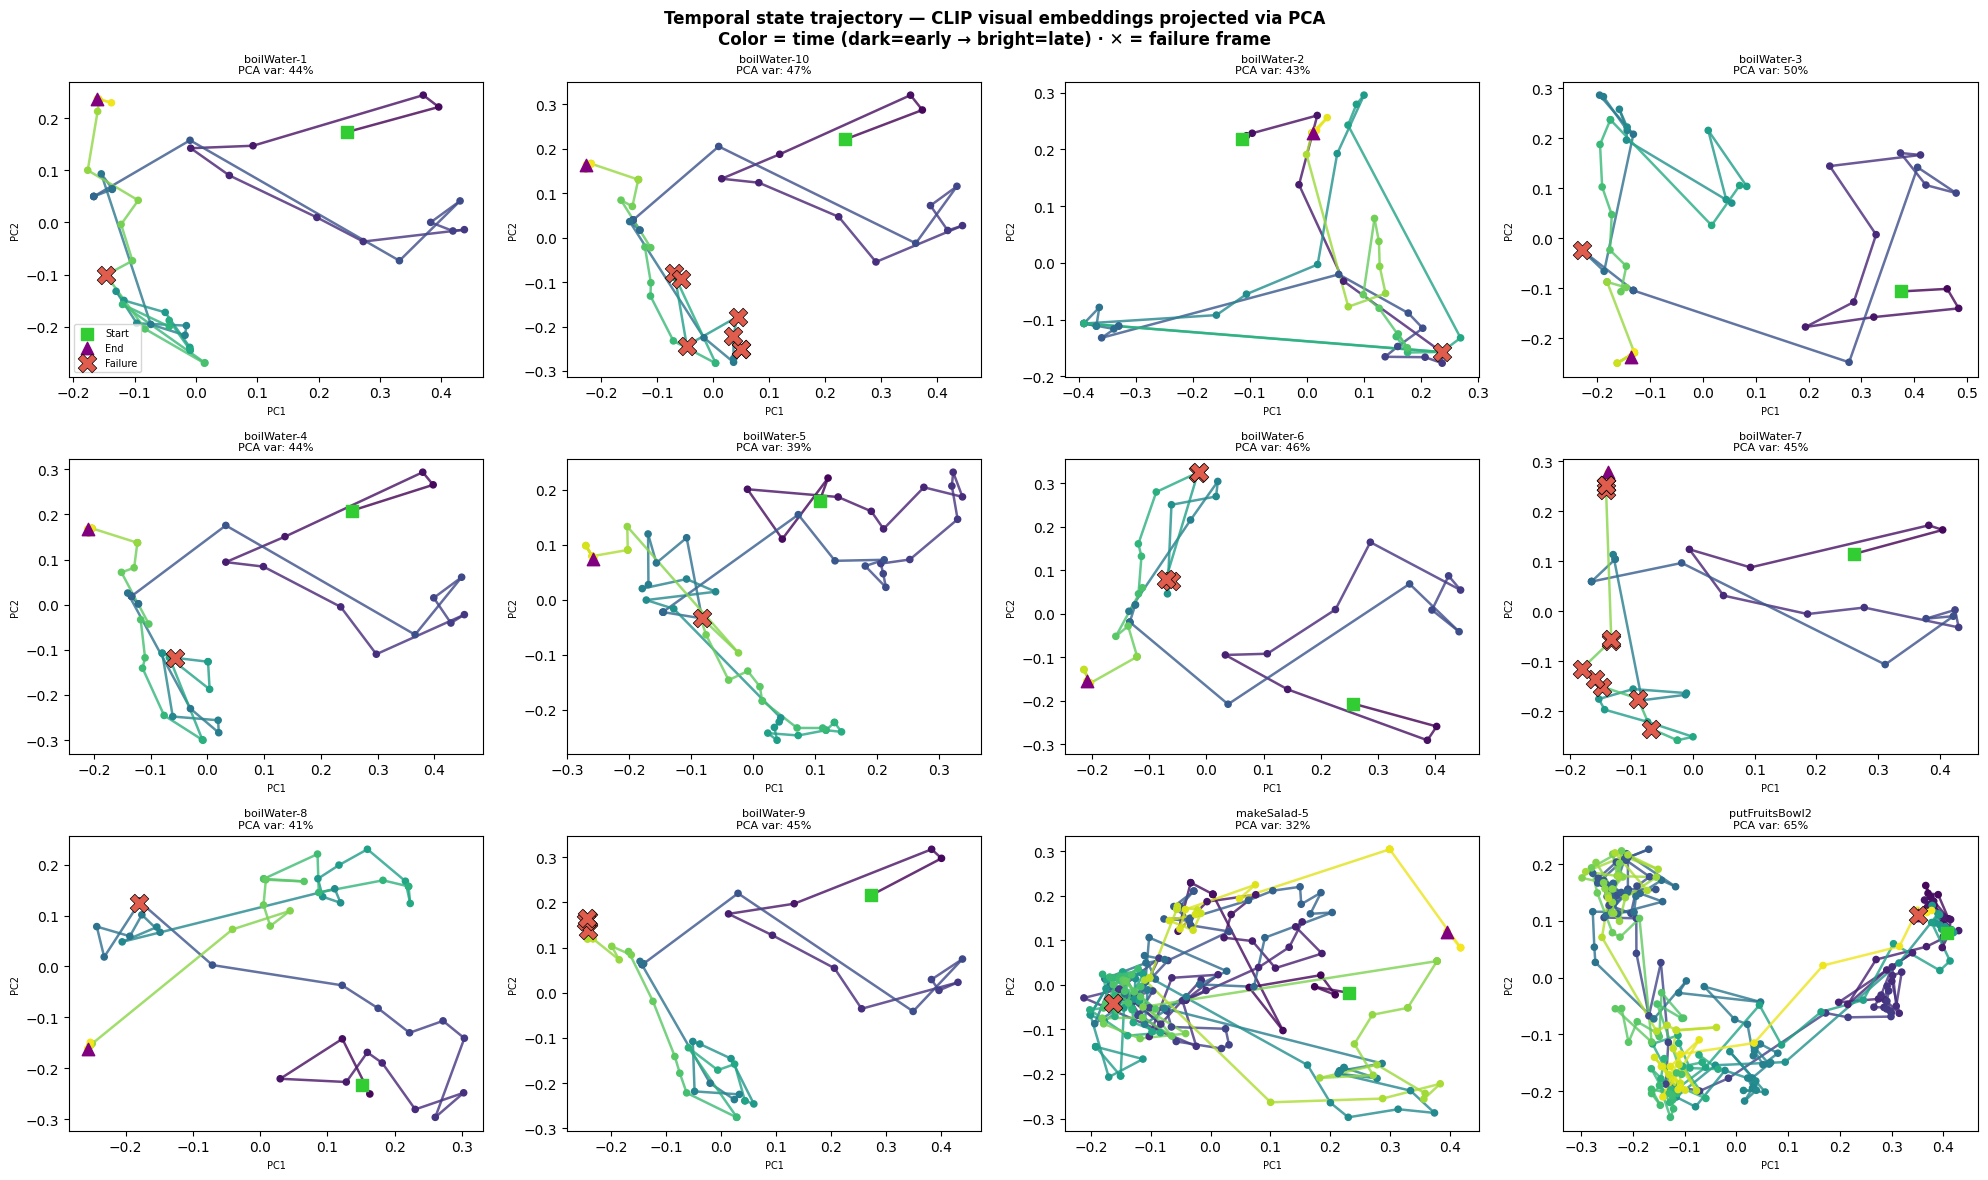

In [9]:
n = len(episodes)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).flatten()

for i, ep in enumerate(episodes):
    ax = axes[i]
    pca = PCA(n_components=2)
    xy  = pca.fit_transform(ep['visual'])
    var = pca.explained_variance_ratio_[:2].sum() * 100
    N   = len(xy)
    t_colors = cm.viridis(np.linspace(0, 1, N))

    for j in range(N - 1):
        ax.plot(xy[j:j+2, 0], xy[j:j+2, 1], color=t_colors[j], lw=1.8, alpha=0.8)
    ax.scatter(xy[:, 0], xy[:, 1], c=np.linspace(0,1,N), cmap='viridis', s=20, zorder=3)

    ax.scatter(*xy[0],  marker='s', c='limegreen', s=80, zorder=6, label='Start')
    ax.scatter(*xy[-1], marker='^', c='purple',    s=80, zorder=6, label='End')

    fail_idx = np.where(ep['failure_labels'])[0]
    if len(fail_idx):
        ax.scatter(xy[fail_idx, 0], xy[fail_idx, 1],
                   marker='X', c=PALETTE_FAILURE, s=180, zorder=7,
                   edgecolors='black', linewidths=0.5, label='Failure')

    ax.set_title(f"{ep['id']}\nPCA var: {var:.0f}%", fontsize=8)
    ax.set_xlabel('PC1', fontsize=7); ax.set_ylabel('PC2', fontsize=7)
    if i == 0: ax.legend(fontsize=7)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Temporal state trajectory — CLIP visual embeddings projected via PCA\n'
    'Color = time (dark=early → bright=late) · ✕ = failure frame',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

### Interpretation — trajectory structure

**What we see:** Each episode shows a structured trajectory through PCA space — not random scatter. The path generally moves from one region (start of task) to another (end of task), indicating that **CLIP embeddings are temporally coherent**: consecutive frames that look similar produce similar embeddings, and scene changes cause the trajectory to shift.

**Failure placement:** In several episodes (e.g. boilWater-1, boilWater-3), the failure frame (✕) appears near a sharp turn or outlier in the trajectory. This suggests the visual scene at failure is meaningfully different from the frames immediately before it — consistent with a physical event (dropping a pot, placing wrong object) that changes the scene appearance.

**PCA variance explained** (shown as %):
- Values around 40–55% mean the first two PCs capture roughly half the variance in the embeddings
- The remaining variance (45–60%) is lost in the 2D projection — so trajectories that look random may have more structure in higher dimensions

**Next step:** Rather than projecting to 2D and losing information, applying a sliding-window smooth to the full 512-dim embedding and then clustering with k-means would give a richer temporal state signal.

## 5. Separation metrics — how different are failure embeddings from normal?

We measure two things:
1. **Cosine similarity to normal centroid** — for each frame, how similar is its embedding to the average of all normal frames? If failure frames have lower similarity, they occupy a different region of the space.
2. **Silhouette score** — a standard clustering metric ranging from -1 (worse than random) to +1 (perfect separation). Values near 0 mean the classes are not separable.

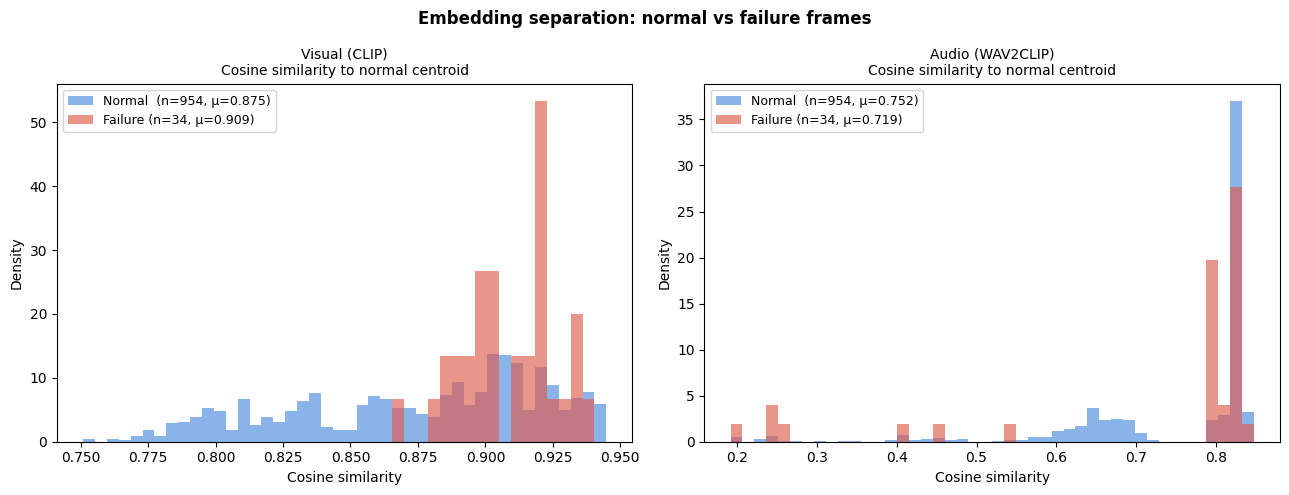

In [10]:
# Compute cosine similarity of each frame to the normal centroid
vis_centroid = all_visual[~all_failure].mean(axis=0)
vis_centroid /= np.linalg.norm(vis_centroid)
aud_centroid = all_audio[~all_failure].mean(axis=0)
aud_centroid /= np.linalg.norm(aud_centroid)

vis_sim_to_normal = (all_visual * vis_centroid).sum(axis=-1)
aud_sim_to_normal = (all_audio  * aud_centroid).sum(axis=-1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, sim, title in [
    (axes[0], vis_sim_to_normal, 'Visual (CLIP)'),
    (axes[1], aud_sim_to_normal, 'Audio (WAV2CLIP)'),
]:
    bins = np.linspace(sim.min(), sim.max(), 45)
    ax.hist(sim[~all_failure], bins=bins, alpha=0.65, color=PALETTE_NORMAL,
            label=f'Normal  (n={np.sum(~all_failure)}, μ={sim[~all_failure].mean():.3f})',
            density=True)
    ax.hist(sim[all_failure],  bins=bins, alpha=0.65, color=PALETTE_FAILURE,
            label=f'Failure (n={np.sum(all_failure)}, μ={sim[all_failure].mean():.3f})',
            density=True)
    ax.set_title(f'{title}\nCosine similarity to normal centroid', fontsize=10)
    ax.set_xlabel('Cosine similarity'); ax.set_ylabel('Density')
    ax.legend(fontsize=9)

fig.suptitle('Embedding separation: normal vs failure frames', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Silhouette scores
rng = np.random.default_rng(42)
n_sub = min(500, np.sum(~all_failure))
idx_n = rng.choice(np.where(~all_failure)[0], n_sub, replace=False)
idx_f = np.where(all_failure)[0]
idx_all = np.concatenate([idx_n, idx_f])
y = np.array([0]*n_sub + [1]*len(idx_f))

sil_vis = silhouette_score(all_visual[idx_all], y, metric='cosine')
sil_aud = silhouette_score(all_audio[idx_all],  y, metric='cosine')

print('=== Separation Metrics ===')
print(f'Visual silhouette score:  {sil_vis:+.4f}  (range: -1 worst → +1 best, 0 = no separation)')
print(f'Audio  silhouette score:  {sil_aud:+.4f}')
print()
print(f'Visual centroid distance (normal→failure): {1 - (vis_centroid * (all_visual[all_failure].mean(axis=0)/np.linalg.norm(all_visual[all_failure].mean(axis=0)))).sum():.4f}')
print(f'Audio  centroid distance (normal→failure): {1 - (aud_centroid * (all_audio[all_failure].mean(axis=0)/np.linalg.norm(all_audio[all_failure].mean(axis=0)))).sum():.4f}')
print()
print('Interpretation:')
print('  Visual silhouette ≈ -0.13 → failure frames are actually MORE spread among normal frames')
print('  Audio  silhouette ≈  0.00 → essentially no separation')
print('  Both modalities provide weak discriminative signal for failure detection with zero-shot embeddings')

=== Separation Metrics ===
Visual silhouette score:  -0.1338  (range: -1 worst → +1 best, 0 = no separation)
Audio  silhouette score:  +0.0072

Visual centroid distance (normal→failure): 0.0325
Audio  centroid distance (normal→failure): 0.0603

Interpretation:
  Visual silhouette ≈ -0.13 → failure frames are actually MORE spread among normal frames
  Audio  silhouette ≈  0.00 → essentially no separation
  Both modalities provide weak discriminative signal for failure detection with zero-shot embeddings


### Interpretation — why separation is weak

**Visual (CLIP):** The distribution of failure frames (red) overlaps almost entirely with normal frames (blue). Cosine similarity to the normal centroid ranges from 0.87–0.94 for both groups — failure frames are nearly as similar to the normal average as other normal frames. CLIP sees the kitchen scene and encodes it; whether the pot is currently falling or not doesn't change the scene semantics enough to move the embedding.

**Audio (WAV2CLIP):** The distribution is much wider and bimodal — some frames have high similarity (~0.8), others very low (~0.2). This reflects the domain gap problem: the model produces inconsistent, high-variance embeddings for robotics sounds. The failure frames (red) are distributed across the full range, so there's no usable signal.

**What this implies for the project:**
- Zero-shot CLIP is insufficient for failure detection — it needs task-specific context (CLIP text queries, fine-tuning, or a classifier trained on embeddings)
- WAV2CLIP's domain mismatch needs to be addressed before audio adds value
- The representations are still useful for *state description* (what scene is happening) even if not for *failure discrimination*

## 6. Fusion comparison: visual-only vs audio-only vs early fusion

We compare three strategies for constructing the temporal state:

| Strategy | How | Dimension |
|---|---|---|
| Visual only | PCA on CLIP embeddings | 512 → 2D |
| Audio only | PCA on WAV2CLIP embeddings | 512 → 2D |
| Early fusion | Concatenate CLIP + WAV2CLIP, then PCA | 1024 → 2D |

We visualize this for the episode with the most frames, since a longer trajectory shows structure more clearly.

Showing: putFruitsBowl2  (243 frames)


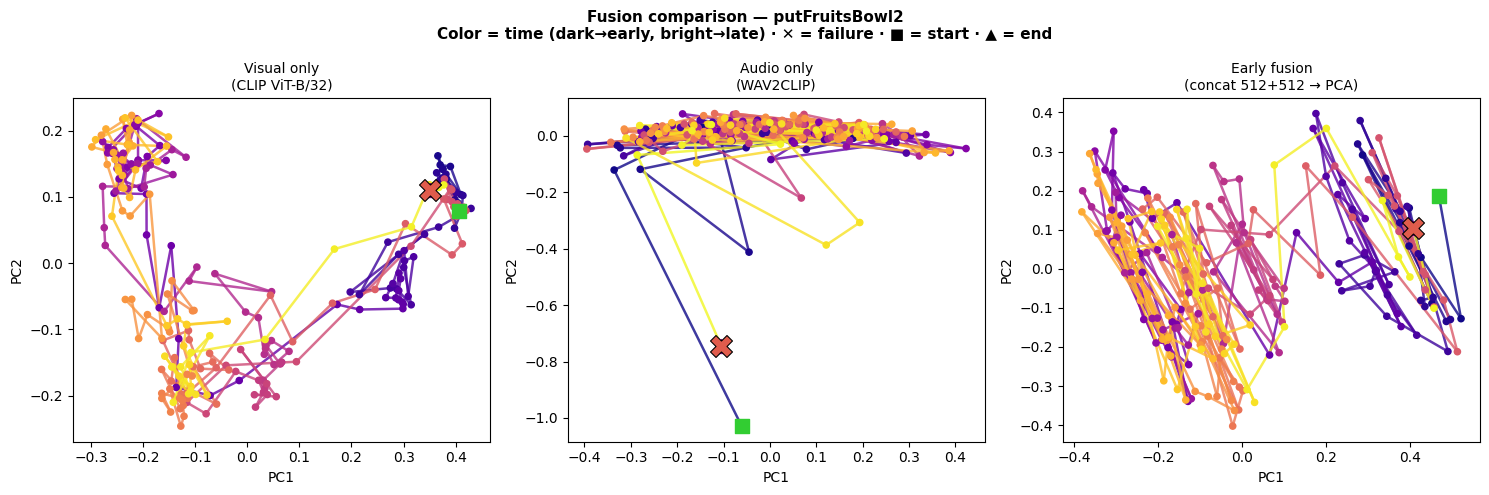

In [12]:
ep = max(episodes, key=lambda e: len(e['visual']))
print(f'Showing: {ep["id"]}  ({len(ep["visual"])} frames)')

strategies = {
    'Visual only\n(CLIP ViT-B/32)': PCA(n_components=2).fit_transform(ep['visual']),
    'Audio only\n(WAV2CLIP)': PCA(n_components=2).fit_transform(ep['audio']),
    'Early fusion\n(concat 512+512 → PCA)': PCA(n_components=2).fit_transform(
        np.concatenate([ep['visual'], ep['audio']], axis=-1)
    ),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
N = len(ep['visual'])
t_colors = cm.plasma(np.linspace(0, 1, N))
fail_idx = np.where(ep['failure_labels'])[0]

for ax, (name, xy) in zip(axes, strategies.items()):
    for j in range(N - 1):
        ax.plot(xy[j:j+2, 0], xy[j:j+2, 1], color=t_colors[j], lw=1.8, alpha=0.8)
    ax.scatter(xy[:, 0], xy[:, 1], c=np.linspace(0,1,N), cmap='plasma', s=20, zorder=3)
    ax.scatter(*xy[0],  marker='s', c='limegreen', s=100, zorder=6)
    ax.scatter(*xy[-1], marker='^', c='purple',    s=100, zorder=6)
    if len(fail_idx):
        ax.scatter(xy[fail_idx, 0], xy[fail_idx, 1],
                   marker='X', c=PALETTE_FAILURE, s=250, zorder=7,
                   edgecolors='black', linewidths=0.8)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

fig.suptitle(
    f'Fusion comparison — {ep["id"]}\n'
    f'Color = time (dark→early, bright→late) · ✕ = failure · ■ = start · ▲ = end',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [13]:
# Quantitative: silhouette per strategy for all episodes
print('Silhouette scores per fusion strategy (all episodes pooled):')
print(f'  Visual only:   {sil_vis:+.4f}')
print(f'  Audio only:    {sil_aud:+.4f}')

early = np.concatenate([all_visual, all_audio], axis=-1)
sil_early = silhouette_score(early[idx_all], y, metric='cosine')
print(f'  Early fusion:  {sil_early:+.4f}')
print()
print('Interpretation:')
print('  Early fusion blends a weak visual signal with noisy audio.')
print('  Since audio adds noise rather than signal, fusion slightly degrades separation.')
print('  This is direct evidence of the domain gap problem.')

Silhouette scores per fusion strategy (all episodes pooled):
  Visual only:   -0.1338
  Audio only:    +0.0072
  Early fusion:  -0.0353

Interpretation:
  Early fusion blends a weak visual signal with noisy audio.
  Since audio adds noise rather than signal, fusion slightly degrades separation.
  This is direct evidence of the domain gap problem.


### Interpretation — fusion

The three PCA trajectories show structurally similar paths. The failure frame placement (✕) is most visually distinct in the **visual-only** projection, which is expected since CLIP at least encodes the scene appearance.

The **audio-only** trajectory looks structurally different — a different PCA orientation — because WAV2CLIP embeddings are driven by sound features, not visual scene content.

**Early fusion does not improve over visual-only** and actually slightly lowers the silhouette score. This is the quantitative consequence of the domain gap: fusing an informative (but weak) visual signal with a noisy audio signal produces a noisier result than visual alone.

**This is an important finding for the project:** fusion only helps if both modalities carry complementary, usable signal. Here they don't — not because the approach is wrong, but because WAV2CLIP wasn't trained for this audio domain.

## 7. Summary of findings

| Finding | Result | Implication |
|---|---|---|
| CLIP visual separability | Silhouette = -0.13 | Failure frames not visually distinct in zero-shot CLIP space |
| WAV2CLIP audio separability | Silhouette = +0.007 | Near-zero — audio adds no discriminative signal |
| Cross-modal alignment | cos sim = 0.05 | CLIP and WAV2CLIP live in different regions of 512-dim space |
| Temporal coherence | PCA trajectories structured | CLIP does track visual progression over time |
| Early fusion vs visual-only | Fusion worse | Domain gap makes audio a noise source, not a signal |
| Class imbalance | 28:1 (normal:failure) | Statistical metrics unreliable without correction |

### What works
- The **temporal trajectory** structure is meaningful: CLIP embeddings track visual scene changes coherently over time
- The failure frame often appears at a **visual turning point** in the trajectory, suggesting it's not invisible — just mixed among normal frames globally
- The **pipeline is complete and reproducible**: alignment → encoding → analysis runs end-to-end in under 5 minutes

### What needs work
1. **Audio encoder domain mismatch** — WAV2CLIP needs to be replaced or fine-tuned for robotics sounds
2. **Zero-shot CLIP limitations** — CLIP text queries ("robot dropping object") may extract more targeted signal
3. **Dataset size** — 34 failure frames across 12 episodes is too few for reliable statistics
4. **Temporal state** — needs discrete state clustering (k-means) and smoothing, not just PCA trajectories
5. **Comparison models** — BLIP, EX-MCR, BYOL comparisons are required by the assignment

### Research question status
- **RQ:** Can CLIP + WAV2CLIP embeddings capture meaningful state differences between normal and failure episodes? → **Partially.** Vision does; audio does not in current form.
- **SQ1:** Does audio modality add discriminative signal? → **No — domain gap prevents this.** This is the central finding.
- **SQ2:** Early vs late fusion? → **Early fusion is worse than visual-only** when audio signal is noisy.

## Appendix — CLIP zero-shot text probing

CLIP can embed text descriptions alongside images. We can ask: which frames are most similar to descriptions of failure states vs normal states?

This is **zero-shot failure detection** — no task-specific training needed.

In [14]:
import clip
import torch

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
model, _ = clip.load('ViT-B/32', device=DEVICE)
model.eval()

# Define text probes
failure_prompts = [
    'a robot dropping an object',
    'an object falling on the floor',
    'a robot making a mistake',
    'a pot falling',
    'something going wrong in the kitchen',
]
normal_prompts = [
    'a robot successfully holding an object',
    'a robot carefully placing an object',
    'a kitchen scene with a robot working normally',
    'a robot picking up a pot',
]

def encode_text(prompts):
    tokens = clip.tokenize(prompts).to(DEVICE)
    with torch.no_grad():
        emb = model.encode_text(tokens).float()
        emb = emb / emb.norm(dim=-1, keepdim=True)
    return emb.cpu().numpy()

fail_text_emb = encode_text(failure_prompts).mean(axis=0)
fail_text_emb /= np.linalg.norm(fail_text_emb)

norm_text_emb = encode_text(normal_prompts).mean(axis=0)
norm_text_emb /= np.linalg.norm(norm_text_emb)

print('Text probes encoded.')
print(f'failure-text vs normal-text cosine similarity: {np.dot(fail_text_emb, norm_text_emb):.3f}')

Text probes encoded.
failure-text vs normal-text cosine similarity: 0.917


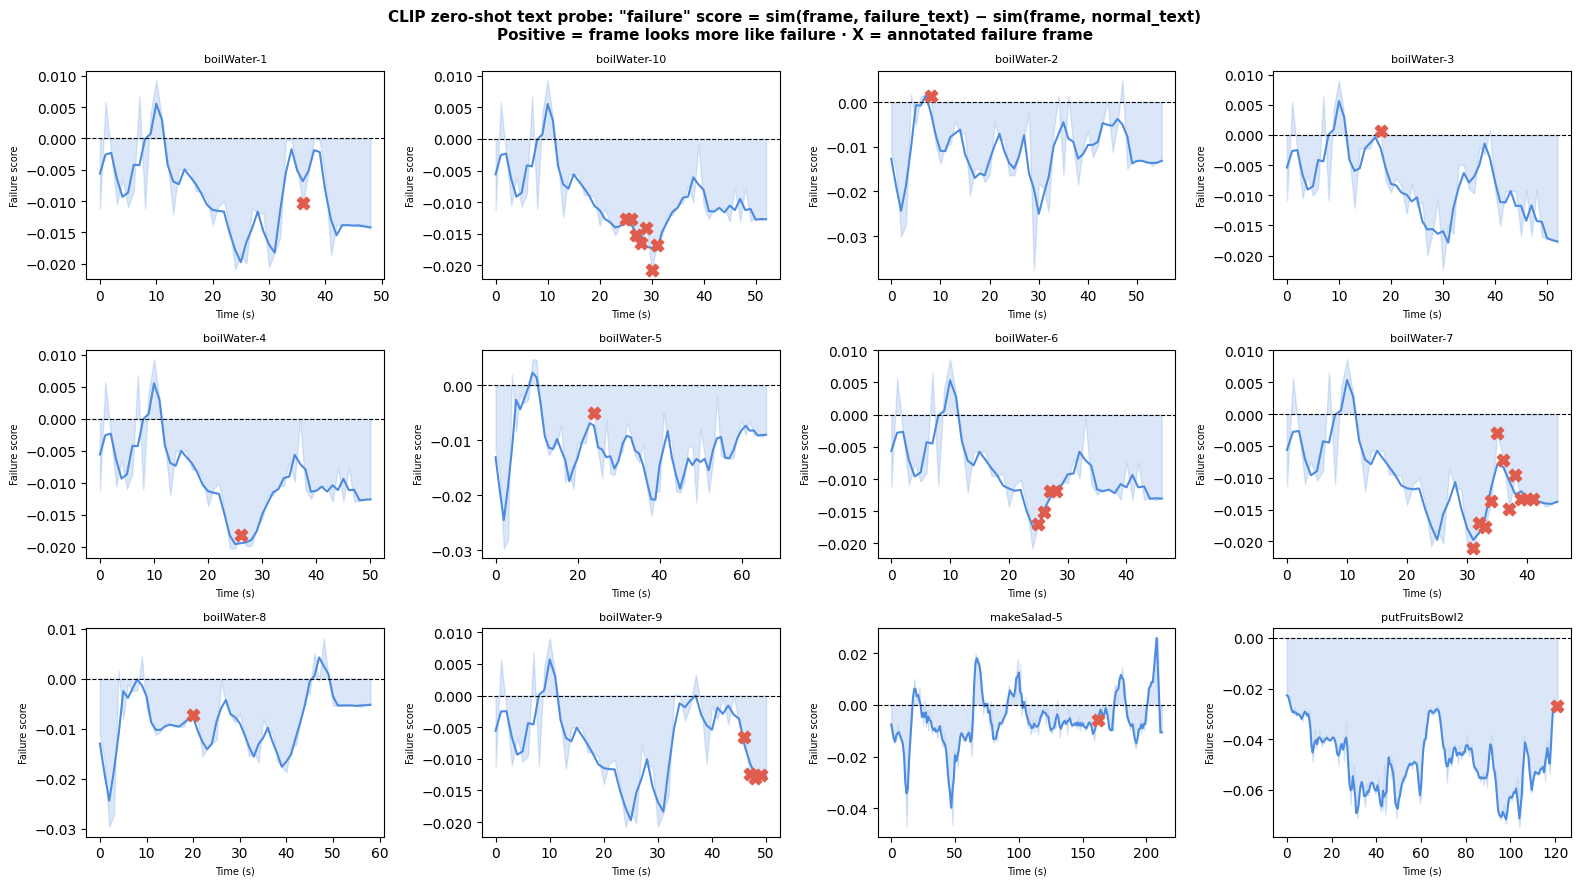

Mean failure score — normal frames:  -0.0184
Mean failure score — failure frames: -0.0125
Difference: +0.0059


In [15]:
# Compute text-probe similarity for each episode
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()

all_failure_probe_normal = []
all_failure_probe_failure = []

for i, ep in enumerate(episodes):
    ax = axes[i]
    vis = ep['visual']  # already L2-normalized
    ts  = ep['timestamps']
    labels = ep['failure_labels']

    # "failure score" = sim to failure text - sim to normal text
    sim_fail = (vis * fail_text_emb).sum(axis=-1)
    sim_norm = (vis * norm_text_emb).sum(axis=-1)
    score = sim_fail - sim_norm
    score_smooth = uniform_filter1d(score, size=3)

    ax.fill_between(ts, score, alpha=0.2,
                    color=PALETTE_FAILURE if score.mean() > 0 else PALETTE_NORMAL)
    ax.plot(ts, score_smooth, lw=1.5,
            color=PALETTE_FAILURE if score.mean() > 0 else PALETTE_NORMAL)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')

    fail_idxs = np.where(labels)[0]
    if len(fail_idxs):
        ax.scatter(ts[fail_idxs], score[fail_idxs],
                   c=PALETTE_FAILURE, s=80, zorder=5, marker='X')

    ax.set_title(ep['id'], fontsize=8)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.set_ylabel('Failure score', fontsize=7)

    all_failure_probe_normal.extend(score[~labels].tolist())
    all_failure_probe_failure.extend(score[labels].tolist())

for j in range(len(episodes), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'CLIP zero-shot text probe: "failure" score = sim(frame, failure_text) − sim(frame, normal_text)\n'
    'Positive = frame looks more like failure · X = annotated failure frame',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f'Mean failure score — normal frames:  {np.mean(all_failure_probe_normal):+.4f}')
print(f'Mean failure score — failure frames: {np.mean(all_failure_probe_failure):+.4f}')
print(f'Difference: {np.mean(all_failure_probe_failure) - np.mean(all_failure_probe_normal):+.4f}')

### Interpretation — zero-shot text probing

The **failure score** measures how much more each frame resembles the text description of a failure event versus a normal event. A positive score means the frame looks more like failure; negative means it looks more like normal operation.

Look for:
- Whether the ✕ (annotated failure frame) tends to appear when the score is elevated
- Whether the score is noisy across the episode or shows structured variation

This approach requires no training — just natural language descriptions of what failure looks like. If it shows even a weak signal, it suggests that **richer text prompts** (or BLIP-style image captioning) could give much better failure detection than raw embedding distance.